<a href="https://colab.research.google.com/github/harveenkaur282-web/ai-ml_labs/blob/main/HEART_DISEASE_PREDCITION_USING_LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Heart Disease Data Set from UCI data repository:  It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them.  


Objective: The objective of this project is to develop a machine learning model which can predict whether a  particular person has heart disease or not? and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

Dataset Link: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data



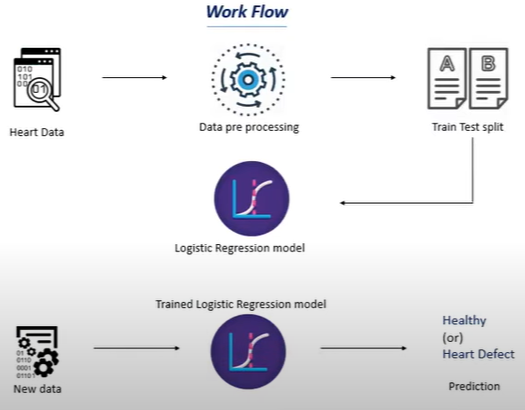

IMPORT THE DEPENDENCIES/ NECESSARY LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import warnings
warnings.filterwarnings("ignore")

LOAD/IMPORT DATASET AND DO PREPROCESSING:


In [2]:
heart_disease_dataset = pd.read_csv('/content/heart_disease_data.csv')
print(heart_disease_dataset)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

### DISPLAY FIRST FIVE ROWS OF DATASET
heart_disease_dataset.head() # show the first five rows
heart_disease_dataset.head(10) # show the first ten rows

In [3]:

heart_disease_dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
heart_disease_dataset.shape
rows = heart_disease_dataset.shape[0]
columns = heart_disease_dataset.shape[1]
print("The no. of rows in heart disease dataset is:", rows)
print("The no of columns in heart disease dataset is:",  columns)

The no. of rows in heart disease dataset is: 1025
The no of columns in heart disease dataset is: 14


In [5]:
heart_disease_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
heart_disease_dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
heart_disease_dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
heart_disease_dataset['target'].value_counts()

,count
target,
1,526
0,499


1.....> having heart disease
0......> Healthy hearth

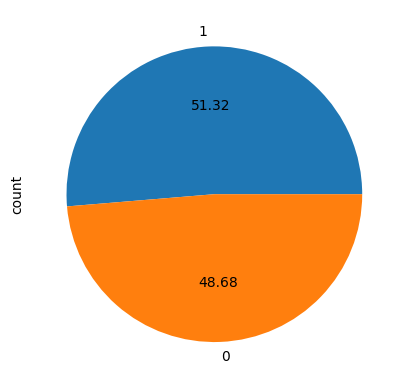

In [9]:
heart_disease_dataset['target'].value_counts().plot(kind = 'pie', autopct = '%0.2f')
plt.show()

In [10]:
X = heart_disease_dataset.drop(columns = 'target', axis = 1)
Y = heart_disease_dataset['target']
print(X)


      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

In [11]:
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


SPLITING THE DATASET INTO TRAINING DATA AND TEST DATA

In [12]:
[X_train, X_test, Y_train, Y_test] = train_test_split(X,Y, test_size = 0.20, stratify = Y, random_state = 2)
print(X.shape, X_train.shape, X_test.shape)

(1025, 13) (820, 13) (205, 13)


MODEL LOADING AND MODEL TRAINING

In [13]:
linear_model = LogisticRegression()

In [14]:
linear_model.fit(X_train, Y_train)

LogisticRegression()

In [15]:
print("Intercept (Bias):", linear_model.intercept_)
print("Coefficients (Weights):", linear_model.coef_)

Intercept (Bias): [0.06968949]
Coefficients (Weights): [[ 0.00373869 -1.49048013  0.80311645 -0.01116847 -0.00372215 -0.04959229
   0.43621358  0.03371815 -1.05078714 -0.48149863  0.51066835 -0.7231864
  -0.99673969]]


MODEL PERFORMANCE EVALUATION ON TRAINING DATA

In [16]:
X_train_data_prediction = linear_model.predict(X_train)

In [17]:
Y_train.value_counts()

,count
target,
1,421
0,399


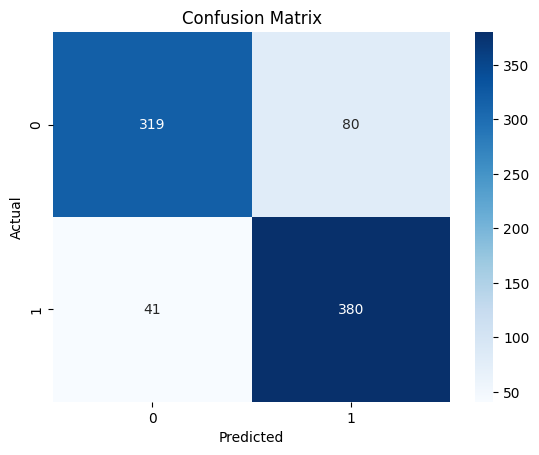

In [18]:
cm = confusion_matrix(Y_train, X_train_data_prediction)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
cm = confusion_matrix(Y_train, X_train_data_prediction)
print(cm)

[[319  80]
 [ 41 380]]


In [20]:
[TN, FP, FN, TP] = confusion_matrix(Y_train, X_train_data_prediction).ravel()
[TN, FP, FN, TP]

[np.int64(319), np.int64(80), np.int64(41), np.int64(380)]

In [21]:
training_data_accuracy =  round(accuracy_score(Y_train, X_train_data_prediction),2)
training_data_precision =  round(precision_score(Y_train, X_train_data_prediction),2)
training_data_recall =  round(recall_score(Y_train, X_train_data_prediction),2)
training_data_f1 =  round(f1_score(Y_train, X_train_data_prediction),2)
print('Accuracy on Training data is : ', training_data_accuracy)
print('Precision on Training data is : ', training_data_precision)
print('Recall on Training data is : ', training_data_recall)
print('F1 on Training data is : ', training_data_f1)

Accuracy on Training data is :  0.85
Precision on Training data is :  0.83
Recall on Training data is :  0.9
F1 on Training data is :  0.86


MODEL EVALUATION ON TEST DATA (MODEL PERFORMANCE ON TEST DATA)

In [22]:
X_test_data_prediction = linear_model.predict(X_test)
test_data_accuracy =  round(accuracy_score(Y_test, X_test_data_prediction),2)
test_data_precision =  round(precision_score(Y_test, X_test_data_prediction),2)
test_data_recall =  round(recall_score(Y_test, X_test_data_prediction),2)
test_data_f1 =  round(f1_score(Y_test, X_test_data_prediction),2)
print('Accuracy on Test data is : ', test_data_accuracy)
print('Precision on Test data is : ', test_data_precision)
print('Recall on Test data is : ', test_data_recall)
print('F1 on Test data is : ', test_data_f1)

Accuracy on Test data is :  0.8
Precision on Test data is :  0.77
Recall on Test data is :  0.89
F1 on Test data is :  0.82


In [23]:
from sklearn.metrics import classification_report
report = classification_report(Y_test, X_test_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1       0.77      0.89      0.82       105

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



In [24]:
[TN, FP, FN, TP] = confusion_matrix(Y_test,X_test_data_prediction).ravel()
[TN, FP, FN, TP]

[np.int64(72), np.int64(28), np.int64(12), np.int64(93)]

In [25]:
cm = confusion_matrix(Y_test,X_test_data_prediction)
print(cm)

[[72 28]
 [12 93]]


In [26]:
Y_test.value_counts()

,count
target,
1,105
0,100


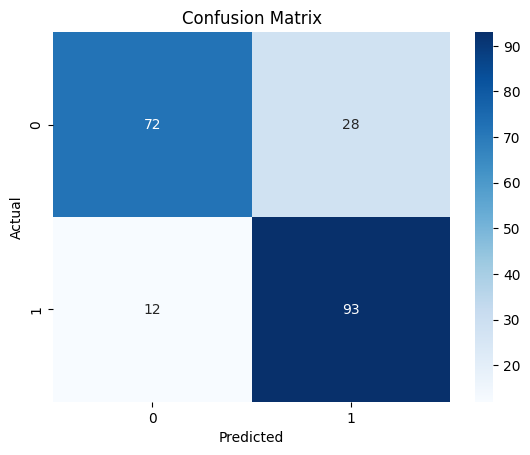

In [27]:
cm = confusion_matrix(Y_test,X_test_data_prediction)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

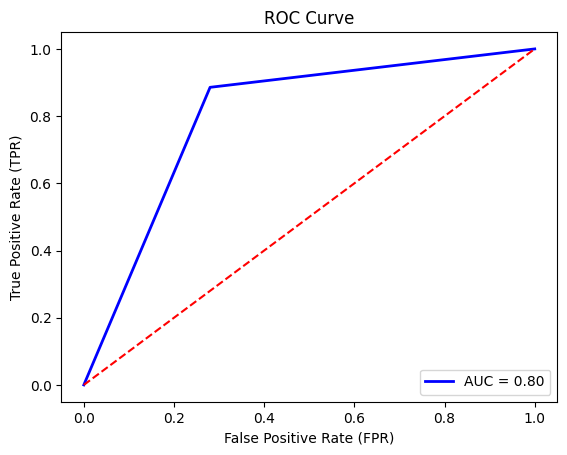

In [28]:
fpr, tpr, _ = roc_curve(Y_test,X_test_data_prediction)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="red", linestyle="dashed")  # Random classifier line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# AUC-ROC (Area Under the Curve - Receiver Operating Characteristic)
AUC-ROC is a performance evaluation metric for classification models, especially in imbalanced datasets.

1. ROC Curve (Receiver Operating Characteristic Curve)
The ROC Curve plots:

  True Positive Rate (TPR) = Recall = Sensitivity (y-axis)

  False Positive Rate (FPR) (x-axis)

It shows how well a model differentiates between positive and negative classes at different threshold values.

2. AUC (Area Under the Curve)

  AUC is the area under the ROC curve.

  Higher AUC (closer to 1.0) means better classification.
  
  AUC = 0.5 → Model is random (no discrimination).

  AUC = 1.0 → Model is perfect (ideal classification).

3. Importance of AUC-ROC

  Works well for imbalanced data.

  Helps in choosing the best threshold for classification.
  
  Compares multiple models effectively.

NOW BUILDING A PREDICTIVE SYSTEM/MODEL

In [29]:
input_data = (58,1,2,132,224,0,0,173,0,3.2,2,2,3)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = linear_model.predict(input_data_reshaped)
print(prediction)
if(prediction[0] == 0):
  print('The person does not have any heart disease')
else:
 print('The person has heart disease')


[0]
The person does not have any heart disease
